# Initial Setup
## Import Packages

In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Import Data
Data is imported from both worksheets to one dataframe each. Both datasets are ordered by date. A sample of both datasets is output as a sense check. 

In [2]:
energy_df = pd.read_excel("data_scientist_tech_challenge.xlsx", sheet_name="energy_data")
energy_df.sort_values(by='date', inplace=True)
temperature_df = pd.read_excel("data_scientist_tech_challenge.xlsx", sheet_name="temperature_data")
temperature_df.sort_values(by='date', inplace=True)
print("energy dataset")
display(energy_df.head(10))
print("temperature dataset")
display(temperature_df.head(10))

energy dataset


,date,total_consumption_kwh
0,2022-07-04,539.59
1,2022-07-05,544.31
2,2022-07-06,558.02
3,2022-07-07,489.05
4,2022-07-08,672.70
5,2022-07-09,754.79
6,2022-07-10,646.11
7,2022-07-11,639.85
8,2022-07-12,645.14
9,2022-07-13,654.46


temperature dataset


,date,average_temperature
364,2022-08-04,16.6
363,2022-08-05,15.3
362,2022-08-06,15.7
361,2022-08-07,17.5
360,2022-08-08,19.8
359,2022-08-09,20.4
358,2022-08-10,21.9
357,2022-08-11,22.6
356,2022-08-12,23.7
355,2022-08-13,23.9


Both datasets appear to be daily records with a date field and corresponding measurements of either energy consumption or average temperature.

# 1. Describe Data
Get row counts and basic aggregations across both datasets

In [3]:
print("Dataset sizes\nEnergy Data: {}, Temperature Data: {}".format(len(energy_df), len(temperature_df)))
display(energy_df.aggregate(['count', 'min', 'max', 'mean','median', 'std']))
display(temperature_df.aggregate(['count', 'min', 'max', 'mean', 'median', 'std']))

Dataset sizes
Energy Data: 1067, Temperature Data: 1093


,date,total_consumption_kwh
count,1067,1067.000000
min,2022-07-04 00:00:00,213.470000
max,2025-07-31 00:00:00,1550.170000
mean,2024-02-02 03:27:50.103092,472.642043
median,2024-02-03 00:00:00,450.230000
std,317 days 20:33:11.066032,101.266122


,date,average_temperature
count,1093,1093.000000
min,2022-08-04 00:00:00,-3.400000
max,2025-07-31 00:00:00,25.200000
mean,2024-02-01 00:00:00,11.137145
median,2024-02-01 00:00:00,11.200000
std,315 days 15:59:21.985189,5.388498


The energy dataset has fewer rows despite data beginning 1 month earlier than the temperature data. Some observations must be missing from the energy consumption dataset. Both datasets end on the same date.

## Date gap analysis
Gaps between observations are analysed to check for observation frequency and any missing observations.

In [4]:
energy_date_gaps = pd.DataFrame(energy_df["date"]) 
energy_date_gaps["date_gap"] = energy_date_gaps["date"].diff().dt.days
print(energy_date_gaps["date_gap"].aggregate(['min', 'max', 'mean']))
missing_obs = energy_date_gaps[energy_date_gaps['date_gap']>1.0]
print(missing_obs)
print("number of gaps: ", len(missing_obs))
print("missing days: ",sum(missing_obs['date_gap'])-len(missing_obs))

min      1.000000
max     32.000000
mean     1.053471
Name: date_gap, dtype: float64
          date  date_gap
27  2022-08-31      32.0
102 2022-11-17       4.0
131 2022-12-18       3.0
197 2023-02-23       2.0
263 2023-05-06       7.0
493 2023-12-25       4.0
581 2024-03-23       2.0
682 2024-07-08       7.0
814 2024-11-20       4.0
876 2025-01-22       2.0
number of gaps:  10
missing days:  57.0


The energy dataset has a gap of 32 day between observations on 2022-07-30 and 2022-08-31. There are also other gaps of 1 week or less in the dataset. In total there are 57 days missing across 10 seperate stretches.

In [5]:
temperature_date_gaps = pd.DataFrame(temperature_df["date"])
temperature_date_gaps["date_gap"] = temperature_date_gaps["date"].diff().dt.days
print(temperature_date_gaps["date_gap"].aggregate(['min', 'max', 'mean']))
print(temperature_date_gaps[temperature_date_gaps['date_gap']!=1.0])

min     1.0
max     1.0
mean    1.0
Name: date_gap, dtype: float64
          date  date_gap
364 2022-08-04       NaN


The energy data starts in July 22 but is then missing all dates in August 22. The temperature data starts in August 22 with no missing dates. This means dates with reliable data from both datasets start from 2022-08-31.

# Data Insights
## Energy Data

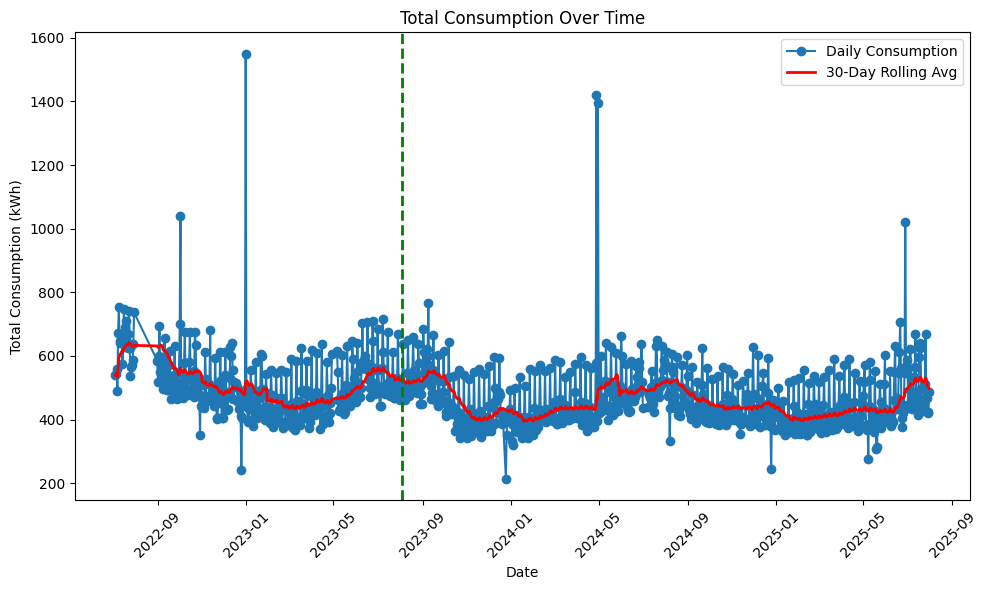

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(energy_df["date"], energy_df['total_consumption_kwh'], marker='o', label='Daily Consumption')
# Calculate and plot 30-day rolling average
energy_df['consumption_rolling_avg_30'] = energy_df['total_consumption_kwh'].rolling(window=30, min_periods=1).mean()
plt.plot(energy_df["date"], energy_df['consumption_rolling_avg_30'], color='red', linewidth=2, label='30-Day Rolling Avg')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023 - Optimisation Date')
plt.show()

Some large outliers are skewing the y-axis scale. Plot the data excluding the large outliers for a better sense of trends.

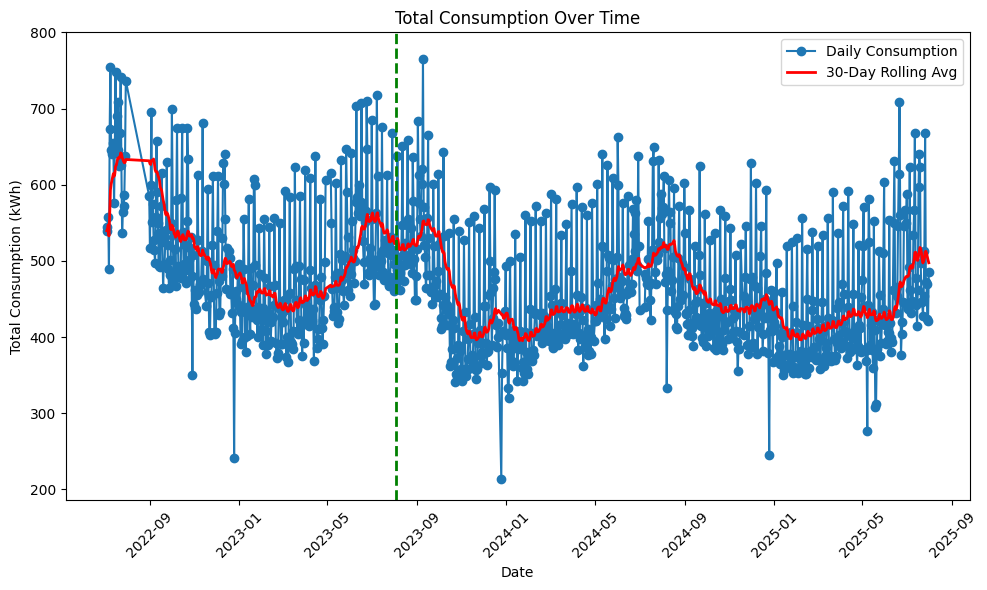

In [7]:
energy_df_filtered = energy_df[energy_df['total_consumption_kwh'] < 800]
plt.figure(figsize=(10, 6))
plt.plot(energy_df_filtered["date"], energy_df_filtered['total_consumption_kwh'], marker='o', label='Daily Consumption')
# Calculate and plot 30-day rolling average
energy_df_filtered['consumption_rolling_avg'] = energy_df_filtered['total_consumption_kwh'].rolling(window=30, min_periods=1).mean()
plt.plot(energy_df_filtered["date"], energy_df_filtered['consumption_rolling_avg'], color='red', linewidth=2, label='30-Day Rolling Avg')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.ylim(top=800)
plt.xticks(rotation=45)
plt.legend()
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023 - Optimisation Date')
plt.tight_layout()
plt.show()

The energy consumption has regular spikes while also following a broader seasonal trend of peaks and dips each year. There are also some extreme high outliers (removed from second graph) and some lows.

### Day of week
To investigate the regularly occuring spikes in energy consumption the data is aggregated by day of week. When doing this analysis the large outlier days of over 800kWh are removed to avoid them skewing the results.

,mean,median
day_of_week,,
Monday,432.049020,415.31
Tuesday,428.901600,415.57
Wednesday,434.497255,422.00
Thursday,436.920710,431.77
Friday,480.305232,473.05
Saturday,592.908477,590.79
Sunday,477.766242,468.80


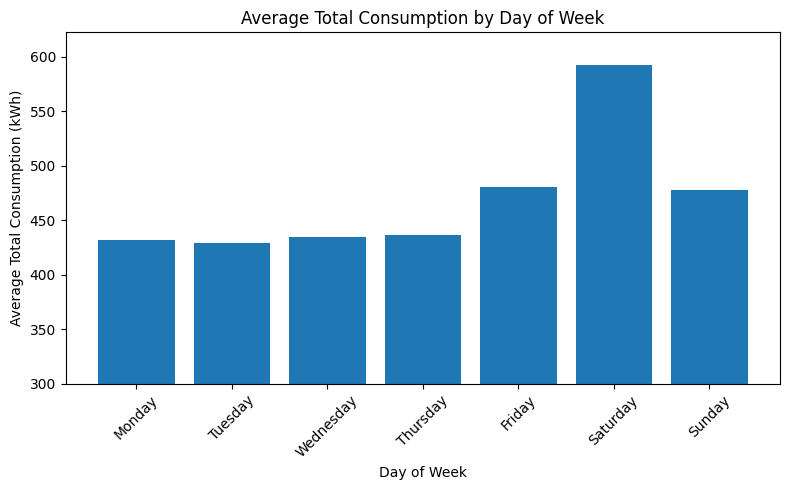

In [8]:
energy_df["day_of_week"] = energy_df["date"].dt.day_name()
day_of_week_consumption = energy_df[energy_df["total_consumption_kwh"]<800].groupby("day_of_week")['total_consumption_kwh'].aggregate(['mean','median']).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
display(day_of_week_consumption)
plt.figure(figsize=(8, 5))
plt.bar(day_of_week_consumption.index, day_of_week_consumption['mean'])
plt.xlabel('Day of Week')
plt.ylabel('Average Total Consumption (kWh)')
plt.title('Average Total Consumption by Day of Week')
plt.xticks(rotation=45)
plt.ylim(bottom=300)
plt.tight_layout()
plt.show()

Saturday has significantly higher average consumption of 590kWh vs. mid-week days around 430kWh and Fridays and Sundays around 470kWh. To check this pattern is consistent over time the consumption is plotted split by day of week.

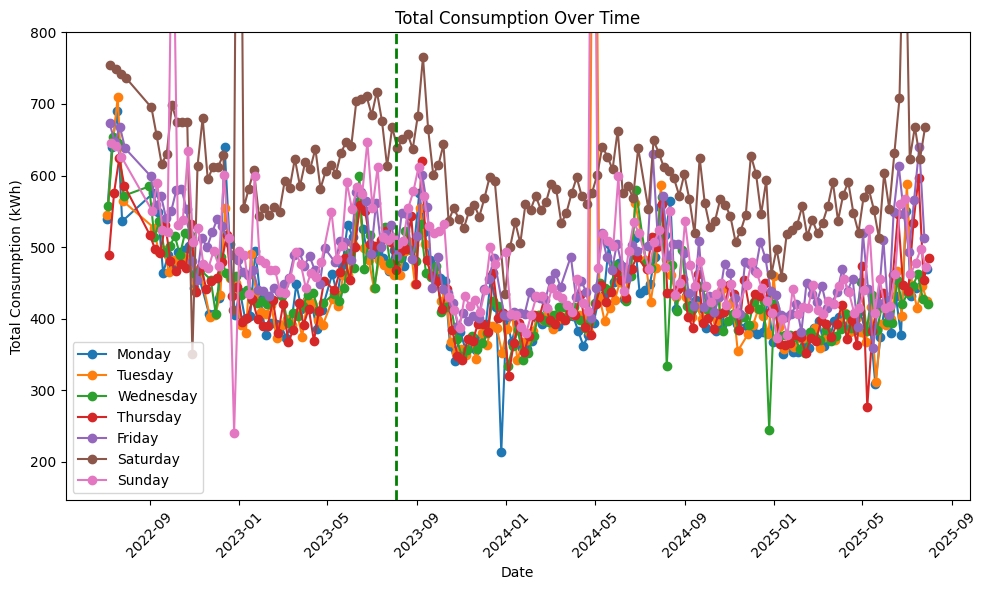

In [9]:
plt.figure(figsize=(10, 6))
for day in list(energy_df["day_of_week"].unique()):
    day_data = energy_df[energy_df["day_of_week"] == day]
    plt.plot(day_data["date"], day_data['total_consumption_kwh'], marker='o', label=day)
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('Total Consumption Over Time')
plt.ylim(top=800)
plt.xticks(rotation=45)
plt.legend()
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023 - Optimisation Date')
plt.tight_layout()
plt.show()

Graph is a bit messy but does show Saturdays have consistently higher consumption and the trend does not change after the optimisation date. Fridays and Sundays also appear to be consistently higher consumption than mid-week.

### Anomaly Investigation
The extreme low values are viewed to investigate any patterns

In [10]:
bottom_values = energy_df.sort_values(by='total_consumption_kwh').head(10)
print("Bottom 10 Total Consumption Values:")
display(bottom_values[["date","day_of_week","total_consumption_kwh"]])

Bottom 10 Total Consumption Values:


,date,day_of_week,total_consumption_kwh
493,2023-12-25,Monday,213.47
138,2022-12-25,Sunday,240.87
849,2024-12-25,Wednesday,244.94
982,2025-05-08,Thursday,277.23
993,2025-05-19,Monday,308.36
994,2025-05-20,Tuesday,312.21
503,2024-01-04,Thursday,319.94
502,2024-01-03,Wednesday,333.49
712,2024-08-07,Wednesday,333.59
433,2023-10-23,Monday,341.21


The three lowest consumption days are all on Christmas. May be due to closure. Potentially add a feature to flag christmas day when modelling.

Extreme high values are also reviewed.

In [11]:
top_values = energy_df.sort_values(by='total_consumption_kwh', ascending=False).head(10)
print("Top 10 Total Consumption Values:")
display(top_values[["date","day_of_week","total_consumption_kwh"]])

Top 10 Total Consumption Values:


,date,day_of_week,total_consumption_kwh
144,2022-12-31,Saturday,1550.17
617,2024-04-28,Sunday,1420.88
619,2024-04-30,Tuesday,1394.65
59,2022-10-02,Sunday,1039.65
1033,2025-06-28,Saturday,1021.74
389,2023-09-09,Saturday,765.51
5,2022-07-09,Saturday,754.79
12,2022-07-16,Saturday,748.30
19,2022-07-23,Saturday,741.96
26,2022-07-30,Saturday,736.63


There doesn't appear to be any clear pattern to the extreme high consumption days. These values could be either capped at 800 to avoid them having an outsized impact on any modelling or excluded from the data completely. 

## Temperature Data
The temperature data is also plotted.

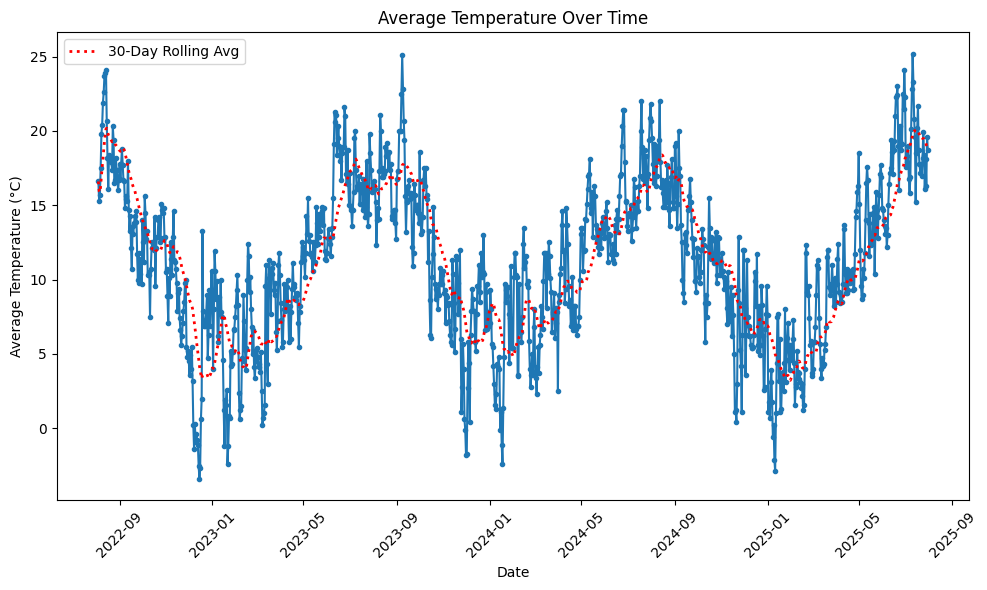

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(temperature_df["date"], temperature_df['average_temperature'], marker='.')
# Calculate and plot 30-day rolling average
temperature_df['temp_rolling_avg_30'] = temperature_df['average_temperature'].rolling(window=30, min_periods=1).mean()
plt.plot(temperature_df["date"], temperature_df['temp_rolling_avg_30'], color='red', linewidth=2, label='30-Day Rolling Avg', linestyle=':')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Ambient temperature follows an expected pattern with daily variation and a seasonal pattern each year getting colder in winter and warmer in summer.

Overlay the energy consumption with the temperature to give an initial view of any correlation. Outlier values of energy consumption are removed to provide a better scale for comparison.

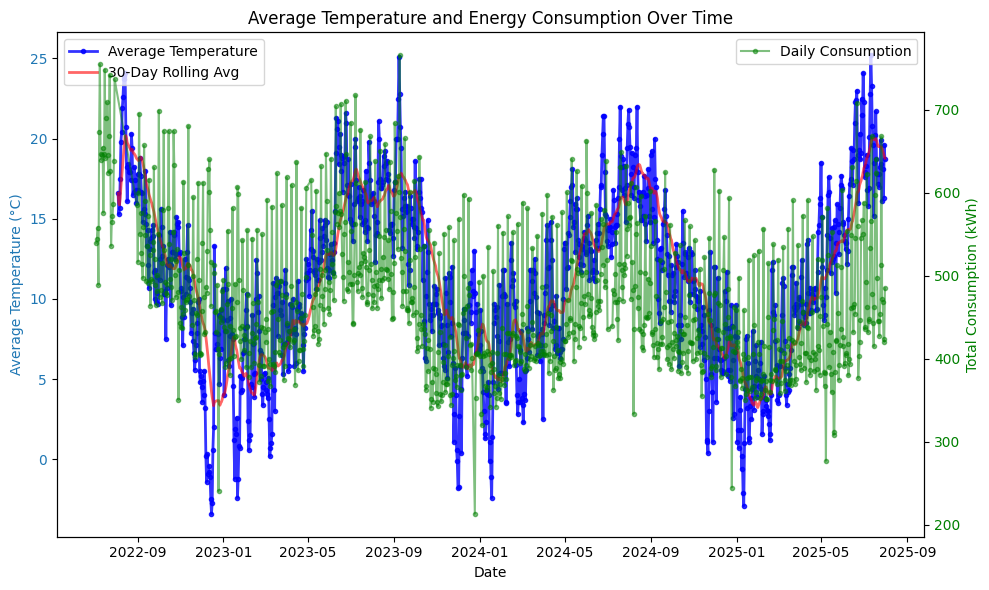

In [13]:
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
# Plot average temperature
ax1.plot(temperature_df["date"], temperature_df['average_temperature'], color='blue', linewidth=2, alpha=0.8, marker='.', label='Average Temperature')
ax1.plot(temperature_df["date"], temperature_df['temp_rolling_avg_30'], color='red', linewidth=2, alpha=0.6, label='30-Day Rolling Avg')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Temperature (°C)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Plot energy consumption on a secondary y-axis (right)
ax2 = ax1.twinx()
ax2.plot(
    energy_df[energy_df["total_consumption_kwh"]<800]["date"],
    energy_df[energy_df["total_consumption_kwh"]<800]['total_consumption_kwh'],
    marker='.', label='Daily Consumption', color='green', alpha=0.5
)
ax2.set_ylabel('Total Consumption (kWh)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('Average Temperature and Energy Consumption Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see that seasonally as temperature goes up so does energy consumption. This could be due to the temperature itself or potentially other factor correlated to temperature e.g. site has more customers on warm days or busier in summer months. 

# Merge Data

Merge both data frames together based on date. A left join from temperature_df is used as temperature data has no missing dates. Early dates before 2022-08-31 where there was no overlapping temperature and energy consumption data are also removed. This gives a reduced sample to train on but does provide more reliable data to work with.

In [14]:
merged_df = pd.merge(left=temperature_df, right=energy_df, on='date', how='left',indicator=True)
merged_df = merged_df[merged_df["date"]>=dt.datetime(2022, 8, 31)]
display(merged_df.head())

,date,average_temperature,temp_rolling_avg_30,total_consumption_kwh,consumption_rolling_avg_30,day_of_week,_merge
27,2022-08-31,16.7,18.721429,584.81,631.373214,Wednesday,both
28,2022-09-01,17.8,18.689655,516.87,627.424828,Thursday,both
29,2022-09-02,16.8,18.626667,599.18,626.483333,Friday,both
30,2022-09-03,17.8,18.666667,695.09,631.666667,Saturday,both
31,2022-09-04,18.8,18.783333,550.79,631.882667,Sunday,both


Check correlation between temperature and energy consumption. Also test correlation between consumption and average temperature of preceeding 7 and 30 day periods. Does the site consume more energy if it has been consistently cold or is it based more on current day temp?

In [15]:
correlation = merged_df['total_consumption_kwh'].corr(merged_df['average_temperature'])
merged_df["temp_rolling_average_7"] = merged_df['average_temperature'].rolling(window=7, min_periods=1).mean()
merged_df['prev_day_avg_temp'] = merged_df['average_temperature'].shift(1)

correlation_rolling_7 = merged_df['total_consumption_kwh'].corr(merged_df['temp_rolling_average_7'])
correlation_rolling_30 = merged_df['total_consumption_kwh'].corr(merged_df['temp_rolling_avg_30'])
correlation_prev_day = merged_df['total_consumption_kwh'].corr(merged_df['prev_day_avg_temp'])
print("Correlation between Total Consumption and Average Temperature: {:.2f}".format(correlation))
print("Correlation between Total Consumption and 7-Day Rolling Average Temperature: {:.2f}".format(correlation_rolling_7))
print("Correlation between Total Consumption and 30-Day Rolling Average Temperature: {:.2f}".format(correlation_rolling_30))
print("Correlation between Total Consumption and Previous Day's Average Temperature: {:.2f}".format(correlation_prev_day))

Correlation between Total Consumption and Average Temperature: 0.35
Correlation between Total Consumption and 7-Day Rolling Average Temperature: 0.31
Correlation between Total Consumption and 30-Day Rolling Average Temperature: 0.32
Correlation between Total Consumption and Previous Day's Average Temperature: 0.33


Consumption has the highest correlation with current day average temperature. Since current day temperature will be highly correlated with previous day and the rolling average temperatures (warm days most likely to be in warm months with warm surrounding days) only the current day temperature will be used in model.

## Feature Engineering
Additional date features created based on parts of the date. Impact of day of week on energy consumption has been analysed earlier which should be important in modelling energy consumption. A Boolean flag for Saturdays and another flag for Fridays and Sundays is created.

Another flag is created to identify Christmas.

Create a boolean feature that defines if the site has underwent energy optimisation yet.

In [16]:
merged_df["day_of_week"] = merged_df["date"].dt.day_name()
merged_df["is_saturday"] = merged_df["day_of_week"] == "Saturday"
merged_df["is_friday_sunday"] = merged_df["day_of_week"].isin(["Friday", "Sunday"])
merged_df["is_christmas"] = merged_df["date"].dt.month.eq(12) & merged_df["date"].dt.day.eq(25)

merged_df["is_optimised"] = merged_df["date"] >= dt.datetime(2023, 8, 3)

Cap the energy consumption at 800kWh to avoid 

In [17]:
merged_df["total_consumption_capped"] = merged_df["total_consumption_kwh"].clip(upper=800)

# Modelling
## Linear Regression

Data is split between pre and post optimisation activity. Pre optimisation data will be used for training. The model will then be used to predict consumption for the post optimisation. This should give an estimate of what would have happened if nothing had changed.

Records with NA's for the energy consumption are removed from the pre optimisation dataset as they can't be used for training.

In [18]:
pre_optimisation_df = merged_df[merged_df["is_optimised"]==False]
post_optimisation_df = merged_df[merged_df["is_optimised"]==True]
pre_optimisation_df = pre_optimisation_df[pre_optimisation_df["total_consumption_kwh"].isna() == False] # Filter out rows where total_consumption_kwh is NaN
X = pre_optimisation_df[["average_temperature", "is_saturday", "is_friday_sunday","is_christmas"]]

y = pre_optimisation_df["total_consumption_capped"]

The linear regression model is trained on the pre-optimisation data

In [19]:
reg = LinearRegression().fit(X, y)
print("Coefficients: ", reg.coef_)
print("r2 score: ", reg.score(X,y))


Coefficients:  [   5.35657934  159.03603192   53.039212   -263.19307573]
r2 score:  0.6275734520881883


In [20]:
X_predictions = merged_df[["average_temperature", "is_saturday", "is_friday_sunday","is_christmas"]]
y_predictions = reg.predict(X_predictions)
merged_df["predicted_consumption_kwh"] = y_predictions


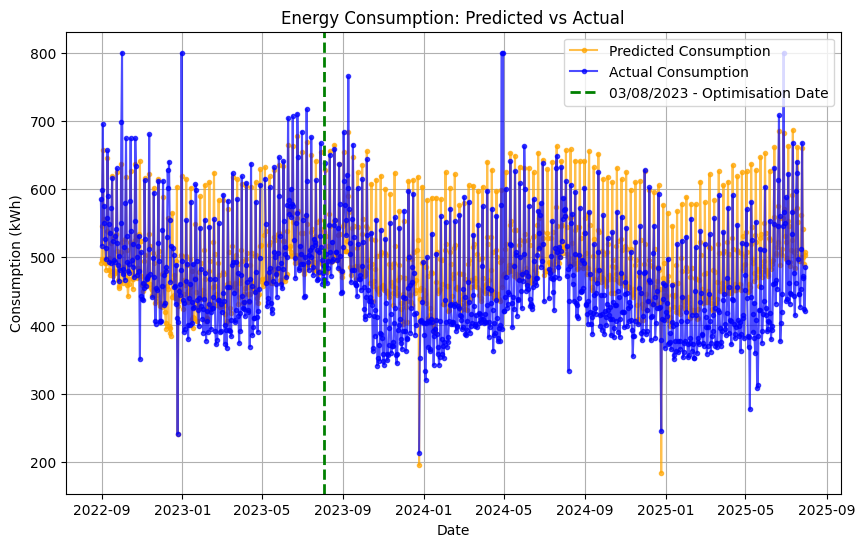

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(merged_df["date"], merged_df['predicted_consumption_kwh'], marker='.', label='Predicted Consumption', color='orange',alpha=0.7)
plt.plot(merged_df["date"], merged_df['total_consumption_capped'], marker='.', label='Actual Consumption', color='blue',alpha=0.7)
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023 - Optimisation Date')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.title('Energy Consumption: Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()

Looking at the plot Actual consumption appears to follow the predicted consumption closely up to the point of undergoing the energy optimisation activity. The Actual consumption then drops below the prediction. This would suggest there has been a reduction in energy consumption after the optimisation activity vs. the expectation if nothing had been changed.

To quantify this we can look at the average consumption vs. prediction both before and after optimisation.

In [22]:
print("Average Actual Consumption and Prediction by Optimisation Status:")
display(merged_df.groupby("is_optimised")[["total_consumption_kwh", "predicted_consumption_kwh"]].mean())
print("Median Actual Consumption and Prediction by Optimisation Status:")
display(merged_df.groupby("is_optimised")[["total_consumption_kwh", "predicted_consumption_kwh"]].median())

Average Actual Consumption and Prediction by Optimisation Status:


,total_consumption_kwh,predicted_consumption_kwh
is_optimised,,
False,498.831446,495.080392
True,454.678601,500.072405


Median Actual Consumption and Prediction by Optimisation Status:


,total_consumption_kwh,predicted_consumption_kwh
is_optimised,,
False,482.32,480.485050
True,432.07,486.912945


Looking across both median and mean we see a minimal difference in the predicted vs. actual consumption before optimisation whereas post optimisation there is roughly a 50kWh reduction in the actual consumption vs. the predicted. This suggests the optimisation activity has reduced energy consumption by approximately 50kWh per day.

## Sarimax Model

### Dataset Preparation

In [23]:
# Set the date as the index and set the frequency (required for time series models)
sarimax_df = merged_df.set_index('date')
sarimax_df = sarimax_df.reindex(pd.date_range(sarimax_df.index.min(), sarimax_df.index.max(), freq='D'))


#Repeat for train and prediction datasets to ensure they are fully indexed and interpolated
sarimax_train_df = sarimax_df[sarimax_df["is_optimised"]==False]
sarimax_train_df = sarimax_train_df.reindex(pd.date_range(sarimax_train_df.index.min(), sarimax_train_df.index.max(), freq='D'))

sarimax_pred_df = sarimax_df[sarimax_df["is_optimised"]==True]
sarimax_pred_df = sarimax_pred_df.reindex(pd.date_range(sarimax_pred_df.index.min(), sarimax_pred_df.index.max(), freq='D'))

# Define endogenous and exogenous variables
endog_train = sarimax_train_df[['total_consumption_capped']]
exog_train = sarimax_train_df[['average_temperature']]

endog_pred = sarimax_pred_df[['total_consumption_capped']]
exog_pred = sarimax_pred_df[['average_temperature']]

endog = sarimax_df[['total_consumption_capped']]
exog = sarimax_df[['average_temperature']]

### Setting (p,d,q),(P,D,Q,s) orders
`s` the seasonal period is 7 days because of the weekly cycle of energy consumption shown earlier so `s=7`

`d` We can't assume any overall long term trends from only 1 year of pre-optimisation data. We assume no overall trend and any trends in the data are seasonal or explained by external factors so set `d=0`

`D` As shown previously we have seen there are strong seasonal trends with high energy consumption on Saturday and lower consumption on weekdays so set `D=1`

To set values for p, q, P and Q the ACF and PACF plots are created.

2022-08-31    584.81
2022-09-01    516.87
2022-09-02    599.18
2022-09-03    695.09
2022-09-04    550.79
               ...  
2023-07-29    667.71
2023-07-30    514.58
2023-07-31    495.51
2023-08-01    460.90
2023-08-02    476.31
Name: total_consumption_capped, Length: 325, dtype: float64

<Figure size 1000x600 with 0 Axes>

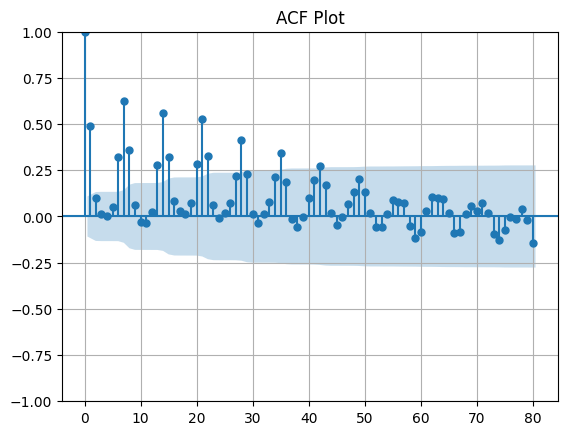

<Figure size 640x480 with 0 Axes>

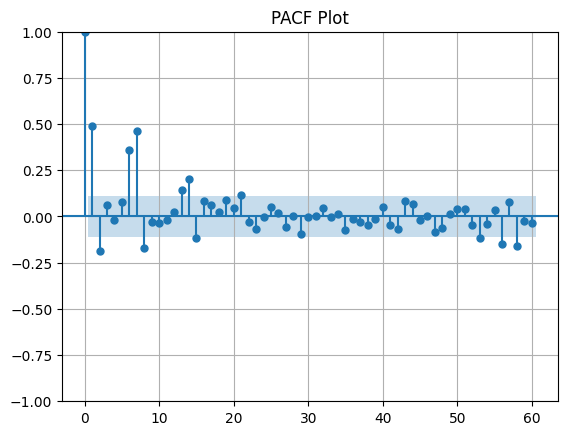

In [24]:
series = sarimax_train_df["total_consumption_capped"].dropna()
display(series)
# create figure
plt.figure(figsize=(10, 6))
plot_acf(series, lags=80)
plt.title("ACF Plot")
plt.grid(True)
plt.show()

plt.figure()
plot_pacf(series, lags=60, method="ywm")
plt.title("PACF Plot")
plt.grid(True)
plt.show()

There are no sharp cut offs in the ACF graph so set `q=0`.

There are significant spikes at the multiples of 7 in the ACF plot so set `Q=1`

There is no sharp cut offs in the PACF plot so set `p=0`

There are no significant spikes in PACF plot at multiples of 7 so set `P=0`

In [25]:
arima_order = (0,0,0) 
seasonal_order = (1,1,1,7)

The sarimax model requires a continuous set of y-values with no missing data.

In [26]:
display(sarimax_train_df["total_consumption_capped"].isna().sum())

np.int64(12)

There are currently 12 missing values. Interpolation can be used to estimate missing values. A more complex method could be used to account for these that could factor in. This would be more important if there were more missing values. 

In [27]:
endog_train=endog_train.interpolate(method='time', inplace=True)

In [28]:
model = SARIMAX(endog=endog_train, exog=exog_train, order=arima_order, seasonal_order=seasonal_order)
results = model.fit(disp=False)
display(results.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                   
====================================================================================
Dep. Variable:     total_consumption_capped   No. Observations:                  337
Model:                SARIMAX(1, 1, [1], 7)   Log Likelihood               -1795.757
Date:                      Thu, 26 Mar 2026   AIC                           3599.514
Time:                              00:23:46   BIC                           3614.710
Sample:                          08-31-2022   HQIC                          3605.576
                               - 08-02-2023                                         
Covariance Type:                        opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
average_temperature     3.8033      0.643      5.919      0.000       2.544       5.063
ar.S.L7                 0.0659      0.068      0.965      0.335      -0.068       0.200
ma.S.L7                -0.8542      0.049    -17.494      0.000      -0.950      -0.759
sigma2               3043.4742    125.151     24.318      0.000    2798.183    3288.765
===================================================================================
Ljung-Box (L1) (Q):                  95.36   Jarque-Bera (JB):              1094.12
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.55   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
sarimax_df["sarimax_predicted_consumption"] = results.get_prediction(start=sarimax_df.index[0], end=sarimax_df.index[-1], exog=exog_pred, dynamic=sarimax_pred_df.index[0]).predicted_mean

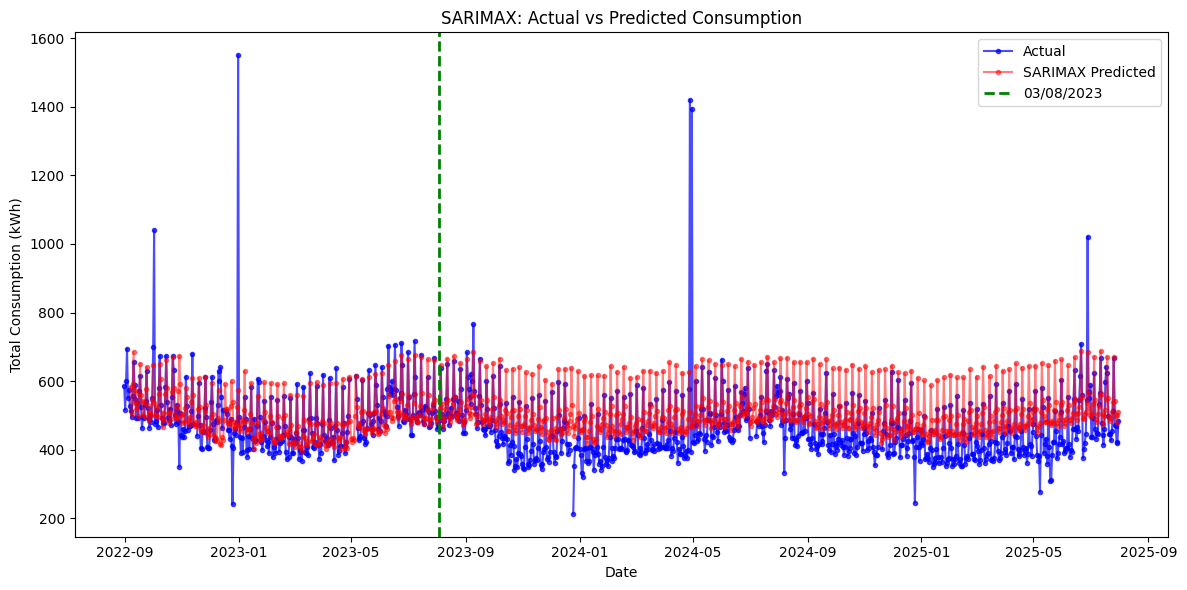

In [30]:
# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(sarimax_df.index, sarimax_df['total_consumption_kwh'], label='Actual', color='blue', alpha=0.7, marker='.')
plt.plot(sarimax_df[sarimax_df.index>'2022-09-06'].index, sarimax_df[sarimax_df.index>'2022-09-06']['sarimax_predicted_consumption'], label='SARIMAX Predicted', color='red', alpha=0.5, marker='.')
plt.axvline(dt.datetime(2023, 8, 3), color='green', linestyle='--', linewidth=2, label='03/08/2023')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kWh)')
plt.title('SARIMAX: Actual vs Predicted Consumption')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
print("Average Actual Consumption and Prediction by Optimisation Status:")
display(sarimax_df.groupby("is_optimised")[["total_consumption_kwh", "sarimax_predicted_consumption"]].mean())
print("Median Actual Consumption and Prediction by Optimisation Status:")
display(sarimax_df.groupby("is_optimised")[["total_consumption_kwh", "sarimax_predicted_consumption"]].median())

Average Actual Consumption and Prediction by Optimisation Status:


,total_consumption_kwh,sarimax_predicted_consumption
is_optimised,,
False,498.831446,490.877597
True,454.678601,508.443280


Median Actual Consumption and Prediction by Optimisation Status:


,total_consumption_kwh,sarimax_predicted_consumption
is_optimised,,
False,482.32,486.295003
True,432.07,489.685531


The SARIMAX model is within 8kWh of the actual consumption on average when predicting the pre-optimisation data whereas the model predicts consumption to be over 50kWh higher than the actual consumption on average post-optimisation. This suggest there has been a significant reduction in the energy consumption on the site post optimisation.